# CME Futures: Portfolio: Allocator Sweep

**Chapter 17 — Portfolio Construction**

With only 30 products across 7 commodity sectors, portfolio construction for
CME futures faces a different constraint than equity case studies: the universe
is narrow enough that concentration choices carry real sector-exposure
implications. Holding the top 10 of 30 products by carry rank is a 33%
concentration — it will often overweight whichever commodity sector is in a
strong contango or backwardation regime.

This notebook sweeps **top predictions × TOP_K concentration × 6 allocators**
to find the best prediction+sizing combination for this case study.

Sections 1–2 generate new allocation backtests (write to registry). Section 3
queries the registry via `BacktestExplorer` and can be re-run independently.

**Learning Objectives:**
1. Sweep top signal-stage predictions × concentration levels × allocation methods
2. Compare equal-weight, score-weighted, inverse-vol, risk-parity, MVO, and HRP
3. Assess how TOP_K interacts with sector concentration in a 30-product universe

**Data caveat**: Results use ratio back-adjusted continuous contracts
(multiplicative adjustment at roll points). See [`13_backtest`](13_backtest.ipynb) preamble for details.

**Book Reference:** Chapter 17, Sections 17.2–17.8

**Prerequisites:** Completed Ch16 backtest with results in `registry.db`.

In [1]:
"""CME Futures: Portfolio: Allocator Sweep."""

import time
import warnings

import polars as pl

warnings.filterwarnings("ignore")

from case_studies.utils.backtest_loaders import (
    get_backtest_config,
    load_backtest_prices_for,
    load_contract_specs_from_yaml,
    warmup_periods_for,
)
from case_studies.utils.backtest_presets import build_backtest_spec
from case_studies.utils.backtest_runner import run_backtest
from case_studies.utils.registry import (
    backtest_hash_from_parts,
    read_predictions,
    resolve_best_predictions,
)
from case_studies.utils.sweep_config import (
    get_allocators,
    get_checkpoints_per_config,
    get_top_k_values_for,
    get_top_n_predictions,
)
from utils.paths import get_case_study_dir

In [2]:
CASE_STUDY_ID = "cme_futures"
LABEL = ""
MAX_SYMBOLS = 0
SKIP_EXPENSIVE_ALLOC = False
TOP_N_PREDICTIONS = None

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_PREDICTIONS is None:
    TOP_N_PREDICTIONS = get_top_n_predictions(CASE_STUDY_ID, "allocation")
CHECKPOINTS_PER_CONFIG = get_checkpoints_per_config(CASE_STUDY_ID)
CONTRACT_SPECS = load_contract_specs_from_yaml()
if not LABEL:
    LABEL = bt_config.primary_label

print(f"Case study: {CASE_STUDY_ID}, label: {LABEL}")

Case study: cme_futures, label: fwd_ret_5d


## 1. Load Top Predictions from Signal Stage

On the primary `fwd_ret_5d` label the signal-stage rank-1 by
equal-weight baseline Sharpe is latent_factors `sdf` (Sharpe 0.72),
ahead of the GBM configurations — `leaves_31_huber` at 0.56 and the
`leaves_7_huber` lineage that later climbs to the cross-stage rank-1 at
0.47. Latent_factors `sdf` on `fwd_ret_21d` carries the highest
signal-stage Sharpe in the case study at 1.13. The allocation sweep
tests whether portfolio sizing (score-weighted, inverse-vol, risk
parity, MVO, HRP, conformal-weighted) improves on the raw signal-stage
results.

In [4]:
top_preds = resolve_best_predictions(
    CASE_STUDY_ID,
    LABEL,
    split="validation",
    stage="signal",
    top_n=TOP_N_PREDICTIONS,
    checkpoints_per_config=CHECKPOINTS_PER_CONFIG,
)
print(f"Top {len(top_preds)} prediction sources by equal-weight baseline Sharpe:")
print(top_preds.select(["source", "sharpe"]))

Top 10 prediction sources by equal-weight baseline Sharpe:
shape: (10, 2)
┌─────────────────────┬──────────┐
│ source              ┆ sharpe   │
│ ---                 ┆ ---      │
│ str                 ┆ f64      │
╞═════════════════════╪══════════╡
│ latent_factors/sdf  ┆ 0.720265 │
│ gbm/leaves_31_huber ┆ 0.560691 │
│ gbm/leaves_15_huber ┆ 0.545163 │
│ gbm/leaves_15_mse   ┆ 0.545163 │
│ tabular_dl/tabm_l   ┆ 0.518816 │
│ gbm/leaves_63_mse   ┆ 0.501802 │
│ gbm/leaves_7_huber  ┆ 0.46946  │
│ gbm/leaves_7_mse    ┆ 0.46946  │
│ gbm/leaves_63_huber ┆ 0.454871 │
│ gbm/leaves_31_mse   ┆ 0.420434 │
└─────────────────────┴──────────┘


In [5]:
prices = load_backtest_prices_for(
    CASE_STUDY_ID,
    LABEL,
    split="validation",
    warmup_periods=warmup_periods_for(CASE_STUDY_ID),
    max_symbols=MAX_SYMBOLS,
)
n_assets = prices["symbol"].n_unique()
print(f"Prices: {len(prices):,} rows, {n_assets} assets")

Prices: 47,634 rows, 30 assets


## 2. Allocation Sweep

For each (prediction × TOP_K × allocator), call `run_backtest()` with the
allocation config added to the strategy spec. The spec hash automatically
differentiates these from signal-stage backtests.

In a 30-product universe, risk-parity and inverse-vol allocators may
inadvertently reduce sector diversification by overweighting low-volatility
products from the same sector. HRP's hierarchical clustering is better suited
to respecting sector structure than naive inverse-vol weighting.

In [6]:
TOP_K_VALUES = get_top_k_values_for(CASE_STUDY_ID, LABEL, n_assets)
print(f"TOP_K grid: {TOP_K_VALUES} (universe: {n_assets} assets)")

_ALL_ALLOC_CONFIGS = get_allocators(CASE_STUDY_ID)

_EXPENSIVE = {"mvo_ledoit_wolf", "hrp"}
if SKIP_EXPENSIVE_ALLOC:
    ALLOC_CONFIGS = [a for a in _ALL_ALLOC_CONFIGS if a["method"] not in _EXPENSIVE]
    print(f"Skipping expensive allocators: {', '.join(sorted(_EXPENSIVE))}")
else:
    ALLOC_CONFIGS = _ALL_ALLOC_CONFIGS

n_total = len(top_preds) * len(TOP_K_VALUES) * len(ALLOC_CONFIGS)
print(
    f"Total backtests: {len(top_preds)} preds × {len(TOP_K_VALUES)} top_k × "
    f"{len(ALLOC_CONFIGS)} allocs = {n_total}"
)

TOP_K grid: [5, 10] (universe: 30 assets)
Total backtests: 10 preds × 2 top_k × 7 allocs = 140


In [7]:
n_done = 0
n_failed = 0
n_skipped = 0
skip_expensive = SKIP_EXPENSIVE_ALLOC
sweep_start = time.monotonic()
BUDGET_SECONDS = 3600

# Load existing backtest hashes to skip completed runs
import sqlite3

_existing_hashes: set[str] = set()
_db_path = get_case_study_dir(CASE_STUDY_ID) / "run_log" / "registry.db"
if _db_path.exists():
    _db = sqlite3.connect(str(_db_path))
    _existing_hashes = {
        r[0] for r in _db.execute("SELECT backtest_hash FROM backtest_runs").fetchall()
    }
    _db.close()
    print(f"Existing backtests in registry: {len(_existing_hashes)}")

for top_k in TOP_K_VALUES:
    print(f"\n--- TOP_K = {top_k} ---")
    for pred_row in top_preds.iter_rows(named=True):
        pred_hash = pred_row["prediction_hash"]
        source = pred_row["source"]

        predictions = read_predictions(CASE_STUDY_ID, pred_hash)

        for alloc in ALLOC_CONFIGS:
            alloc_name = alloc["method"]

            if skip_expensive and alloc_name in _EXPENSIVE:
                continue

            n_done += 1

            spec = build_backtest_spec(
                CASE_STUDY_ID,
                bt_config,
                prices=prices,
                prediction_hash=pred_hash,
                initial_cash=bt_config.initial_cash,
                chapter="ch17",
                signal={
                    "method": "equal_weight_top_k",
                    "top_k": top_k,
                    "long_short": bt_config.long_short,
                },
                allocation={**alloc, "top_k": top_k, "long_short": bt_config.long_short},
            )
            is_expensive = alloc_name in _EXPENSIVE

            # Skip if this exact backtest already exists
            b_hash = backtest_hash_from_parts(pred_hash, spec)
            if b_hash in _existing_hashes:
                n_skipped += 1
                continue

            t0 = time.monotonic()
            print(
                f"  [{n_done}/{n_total}] k={top_k} {source} × {alloc_name}...",
                end="",
                flush=True,
            )

            try:
                result = run_backtest(
                    CASE_STUDY_ID,
                    pred_hash,
                    spec,
                    prices=prices,
                    predictions=predictions,
                    label=LABEL,
                    register=True,
                    initial_cash=bt_config.initial_cash,
                    calendar=bt_config.calendar,
                    contract_specs=CONTRACT_SPECS,
                )

                elapsed = time.monotonic() - t0
                print(f" Sharpe={result.metrics.get('sharpe', 0):.3f} ({elapsed:.0f}s)")

                if is_expensive and not skip_expensive:
                    n_remaining = len(top_preds) * len(TOP_K_VALUES) - 1
                    total_projected = (time.monotonic() - sweep_start) + elapsed * n_remaining
                    if total_projected > BUDGET_SECONDS:
                        print(
                            f"    >> Dropping expensive allocators — projected "
                            f"{total_projected / 60:.0f}m exceeds budget"
                        )
                        skip_expensive = True
            except Exception as e:
                elapsed = time.monotonic() - t0
                n_failed += 1
                print(f" FAILED ({elapsed:.0f}s) — {e}")

print(
    f"\nSweep completed in {(time.monotonic() - sweep_start) / 60:.1f} minutes "
    f"({n_done - n_skipped - n_failed} run, {n_skipped} skipped, {n_failed} failed)"
)

Existing backtests in registry: 695

--- TOP_K = 5 ---
  [1/140] k=5 latent_factors/sdf × equal_weight...

  SKIP backtest (complete (hash=84ef8f0312a5)) — reusing cached result
 Sharpe=0.294 (0s)
  [2/140] k=5 latent_factors/sdf × score_weighted...

  SKIP backtest (complete (hash=f56cb42a93c0)) — reusing cached result
 Sharpe=0.490 (0s)
  [3/140] k=5 latent_factors/sdf × inverse_vol...

  SKIP backtest (complete (hash=e8a78e65f86c)) — reusing cached result
 Sharpe=0.110 (0s)
  [4/140] k=5 latent_factors/sdf × risk_parity...

  SKIP backtest (complete (hash=e889e4eac010)) — reusing cached result
 Sharpe=0.013 (0s)
  [5/140] k=5 latent_factors/sdf × mvo_ledoit_wolf...

...

  SKIP backtest (complete (hash=d4f5d8b88d42)) — reusing cached result
 Sharpe=0.148 (0s)
  [137/140] k=10 gbm/leaves_31_mse × risk_parity...

  SKIP backtest (complete (hash=52b6b6b39c64)) — reusing cached result
 Sharpe=0.064 (0s)
  [138/140] k=10 gbm/leaves_31_mse × mvo_ledoit_wolf...

  SKIP backtest (complete (hash=aecb28db335c)) — reusing cached result
 Sharpe=0.455 (0s)
  [139/140] k=10 gbm/leaves_31_mse × hrp...

  SKIP backtest (complete (hash=0bc5384f6442)) — reusing cached result
 Sharpe=0.044 (0s)
  [140/140] k=10 gbm/leaves_31_mse × conformal_weighted...

  SKIP backtest (complete (hash=aefae951e71f)) — reusing cached result
 Sharpe=0.319 (0s)

Sweep completed in 0.0 minutes (140 run, 0 skipped, 0 failed)


## 3. Allocation Analysis

This section is **read-only** — it queries the registry via `BacktestExplorer`
and can be re-run independently without re-running the sweep.

Across the allocation sweep, `score_weighted` is the best allocator on
average (mean Sharpe 0.42 over 48 combinations, ahead of conformal-weighted
0.30 and inverse-vol 0.24); the gap is widest on the GBM predictions (mean
0.56 vs inverse-vol 0.21 and risk-parity 0.13). Score-weighting sizes by
conviction — it scales each position by the prediction magnitude rather than
by volatility — which suits a 30-product panel where the cross-section is too
thin for equal-weighting to behave as diversification. The volatility-aware
allocators (inverse-vol, risk-parity) are a separate family, examined below.

In [8]:
from case_studies.utils.backtest_explorer import BacktestExplorer

explorer = BacktestExplorer(CASE_STUDY_ID)

### Allocator Comparison

For commodity futures, sector concentration is the primary risk the allocator
must manage. A carry signal concentrated in energies (e.g., crude, heating
oil, natgas all in backwardation simultaneously) will load heavily on a single
macro factor. Volatility-aware allocators that spread weight across sectors
should reduce this concentration risk.

In [9]:
alloc_comparison = explorer.compare_allocators()
print(alloc_comparison)

shape: (6, 5)
┌────────────────────┬─────┬────────────┬─────────────┬────────────┐
│ allocator          ┆ n   ┆ avg_sharpe ┆ best_sharpe ┆ avg_max_dd │
│ ---                ┆ --- ┆ ---        ┆ ---         ┆ ---        │
│ str                ┆ u32 ┆ f64        ┆ f64         ┆ f64        │
╞════════════════════╪═════╪════════════╪═════════════╪════════════╡
│ score_weighted     ┆ 48  ┆ 0.422037   ┆ 0.947014    ┆ -0.493252  │
│ conformal_weighted ┆ 48  ┆ 0.296348   ┆ 1.161617    ┆ -0.376384  │
│ mvo_ledoit_wolf    ┆ 48  ┆ 0.254306   ┆ 0.982205    ┆ -0.165583  │
│ inverse_vol        ┆ 48  ┆ 0.235056   ┆ 1.189192    ┆ -0.394037  │
│ risk_parity        ┆ 48  ┆ 0.15587    ┆ 1.067797    ┆ -0.400251  │
│ hrp                ┆ 48  ┆ -0.01637   ┆ 0.7448      ┆ -0.443736  │
└────────────────────┴─────┴────────────┴─────────────┴────────────┘


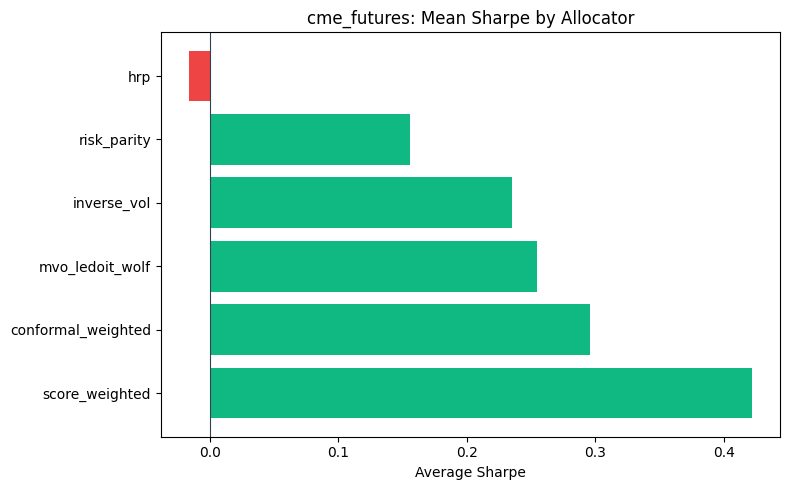

In [10]:
import matplotlib.pyplot as plt

from utils.style import COLORS

if not alloc_comparison.is_empty():
    _allocs = alloc_comparison["allocator"].to_list()
    _sharpes = alloc_comparison["avg_sharpe"].to_list()
    _bar_colors = [COLORS["positive"] if v >= 0 else COLORS["negative"] for v in _sharpes]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(_allocs, _sharpes, color=_bar_colors)
    ax.axvline(0.0, color=COLORS["neutral"], linewidth=0.8)
    ax.set_xlabel("Average Sharpe")
    ax.set_title(f"{CASE_STUDY_ID}: Mean Sharpe by Allocator")
    fig.tight_layout()
    fig.show()

### Top 10 Combinations

The allocation-stage table is topped by the strongest signal-stage family:
latent_factors `sdf` on `fwd_ret_21d`, sized by inverse-vol at top-k=5
(Sharpe +1.19) — the same combination the book reports in §20.5. The
highest-conviction GBM lineage (`leaves_7_huber` × `score_weighted`, top-5)
posts an allocation Sharpe of +0.84 here; it becomes the case study's
*cross-stage* rank-1 only after the risk-overlay stage (Ch19), where the
trailing-stop overlay lifts it to validation Sharpe +1.26. Allocation ranking
and final cross-stage selection therefore name different leaders — an
artifact of the greedy funnel, not a contradiction.

In [11]:
top10 = explorer.best(stage="allocation", top_n=10)
print(top10.select("source", "sharpe", "cagr", "max_drawdown"))

shape: (10, 4)
┌────────────────────┬──────────┬──────────┬──────────────┐
│ source             ┆ sharpe   ┆ cagr     ┆ max_drawdown │
│ ---                ┆ ---      ┆ ---      ┆ ---          │
│ str                ┆ f64      ┆ f64      ┆ f64          │
╞════════════════════╪══════════╪══════════╪══════════════╡
│ latent_factors/sdf ┆ 1.189192 ┆ 0.214807 ┆ -0.165761    │
│ latent_factors/sdf ┆ 1.161617 ┆ 0.217132 ┆ -0.160547    │
│ latent_factors/sdf ┆ 1.067797 ┆ 0.183817 ┆ -0.189902    │
│ latent_factors/sdf ┆ 0.982205 ┆ 0.045417 ┆ -0.095501    │
│ latent_factors/sdf ┆ 0.947014 ┆ 0.254312 ┆ -0.31369     │
│ latent_factors/sdf ┆ 0.942468 ┆ 0.212607 ┆ -0.295148    │
│ latent_factors/sdf ┆ 0.926304 ┆ 0.123962 ┆ -0.167394    │
│ latent_factors/sdf ┆ 0.919078 ┆ 0.118069 ┆ -0.18151     │
│ latent_factors/sdf ┆ 0.912785 ┆ 0.070133 ┆ -0.087415    │
│ latent_factors/sdf ┆ 0.841459 ┆ 0.037061 ┆ -0.072881    │
└────────────────────┴──────────┴──────────┴──────────────┘


## Key Takeaways

1. **The allocation stage and the eventual cross-stage winner name
   different leaders.** Ranked by allocation Sharpe alone, the top slot is
   latent_factors `sdf` on `fwd_ret_21d` with inverse-vol sizing (top-5,
   Sharpe +1.19). The case study's cross-stage rank-1, however, is GBM
   `leaves_7_huber` on `fwd_ret_5d` paired with `score_weighted` (top-5,
   allocation Sharpe +0.84) — it overtakes only after the Ch19 risk overlay
   (validation Sharpe +1.26). Score-weighting sizes by prediction magnitude,
   concentrating in higher-conviction products on a panel where the
   cross-section is too thin for equal-weighting to behave as diversification.
2. The narrow 30-product universe makes sector concentration the primary
   portfolio construction risk. Equal-weight top-k over a carry-ranked universe
   will often concentrate in one or two commodity sectors.
3. TOP_K choices carry different meanings here than in broad equity universes.
   The selected lineage holds k=5 — one-sixth of the panel — trading breadth
   for conviction; larger k (10, 20) dilutes toward holding most of a
   30-product universe, which is not diversification.
4. Volatility-aware allocators (inverse-vol, risk parity) help balance the
   exposure across sectors with very different volatility profiles — energy
   contracts move 2-3x more than treasuries.

Results are registered in `registry.db` for downstream consumption by Ch18
(transaction cost analysis) and Ch19 (risk management overlays).

**Next**: The costs notebook (Ch18) tests cost sensitivity — futures have
very low execution costs (5–15 bps realistic), so the margin of safety is wide.